![](image.png)

## Environment Setup

### Directories

In [1]:
import sys
from pathlib import Path
import importlib

nb_folder = Path().resolve()
PROBLEM_NAME = nb_folder.name
parent_folder = nb_folder.parent
if str(parent_folder) not in sys.path:
    sys.path.insert(0, str(parent_folder))

### Standard Imports

In [2]:
#Standard Imports and class import
from skrom.utils.imports import *
from skrom.rom.rom_utils import *
from skrom.utils.reduced_basis.svd import svd_mode_selector
from skrom.rom.rom_error_est import *
from skrom.utils.visualization.color_palette import set_color_palette
from skrom.utils.visualization.generate_vtk import visualize2D 
import skrom.problem_classes.masterclass as master
problem_mod = importlib.import_module(f"{PROBLEM_NAME}.problem_def") #- this runs @register_problem

PETSc available: True


### Plot Properties

In [3]:
# # Define a custom color palette with 19 distinct colors
set_color_palette();
import sci_mplstyle_package

In [4]:
generate_data = True
visualize = True
run_svd = True
run_rom = True
rom_report = True

## Full Order Simulation

In [5]:
# Conditional execution block for simulation data generation
if generate_data:
    
    # Create an instance of the linear heat conduction simulation
    sim =  master.fom_simulation()
    sim.run_simulation()



Snap 1/64 params=[4.63086453]

Snap 2/64 params=[2.3893352]
Snap 3/64 params=[0.53326214]
Snap 4/64 params=[4.13138384]
Snap 5/64 params=[3.24353376]
Snap 6/64 params=[1.04727303]
Snap 7/64 params=[1.90928656]
Snap 8/64 params=[5.46205186]
Snap 9/64 params=[5.90232092]
Snap 10/64 params=[2.20508082]
Snap 11/64 params=[1.43656761]
Snap 12/64 params=[3.59030113]
Snap 13/64 params=[4.51496768]
Snap 14/64 params=[0.86308399]
Snap 15/64 params=[2.81257094]
Snap 16/64 params=[4.92103587]
Snap 17/64 params=[5.16168503]
Snap 18/64 params=[2.95979874]
Snap 19/64 params=[0.7405229]
Snap 20/64 params=[4.29899111]
Snap 21/64 params=[3.8076531]
Snap 22/64 params=[1.56040972]
Snap 23/64 params=[2.06063717]
Snap 24/64 params=[5.66437329]
Snap 25/64 params=[5.33999424]
Snap 26/64 params=[1.69373576]
Snap 27/64 params=[1.28700931]
Snap 28/64 params=[3.38977168]
Snap 29/64 params=[3.98589491]
Snap 30/64 params=[0.29436852]
Snap 31/64 params=[2.60705756]
Snap 32/64 params=[4.75517701]
Snap 33/64 params=

### Load Simulation Data

In [6]:
# Load saved ROM_data (works even if 'generate=False')
rom_data = master.rom_simulation()

[load_rom_data] loaded from d:\One_drive_folder\OneDrive - Indian Institute of Technology Indian School of Mines Dhanbad\IIT_ISM\RESEARCH\SCIKIT-ROM\scikit-rom\examples\heat_transfer\static\linear\problem_4\ROM_data


## Data Generation

### Generate training solution dataset

In [7]:
# Convert parameter list to a NumPy array (representing system parameters)
# This contains the parameter values for each simulation run (e.g., thermal conductivity, 
# boundary conditions, material properties, etc.)
param_list = np.asarray(rom_data.param_list)

# Load non-linear solutions from the full-order system
# NLS contains the high-fidelity finite element solutions for each parameter set
# Each row represents a complete solution snapshot (discretized spatial field)
LS = np.asarray(rom_data.fos_solutions)

# Split data into training and testing using predefined masks
# These boolean masks determine which snapshots are used for ROM training vs validation
train_mask, test_mask = rom_data.train_mask, rom_data.test_mask

# Apply masks to filter non-linear solutions for training and testing
# Training set: Used to construct the ROM basis functions and train the model
LS_train = LS[train_mask]  # Training snapshots with Dirichlet boundary conditions applied

# Testing set: Used to evaluate ROM accuracy and performance on unseen data
LS_test = LS[test_mask]    # Testing snapshots with Dirichlet boundary conditions applied

# Get the number of snapshots (parameter samples or time instances)
# N_snap: Total number of simulation snapshots available
# Second dimension: Number of degrees of freedom (DOFs) in the spatial discretization
N_snap, _ = np.shape(LS)

# Display the total number of snapshots for verification
print(N_snap)  # Print the number of snapshots available


64


### Training Solution Snapshots

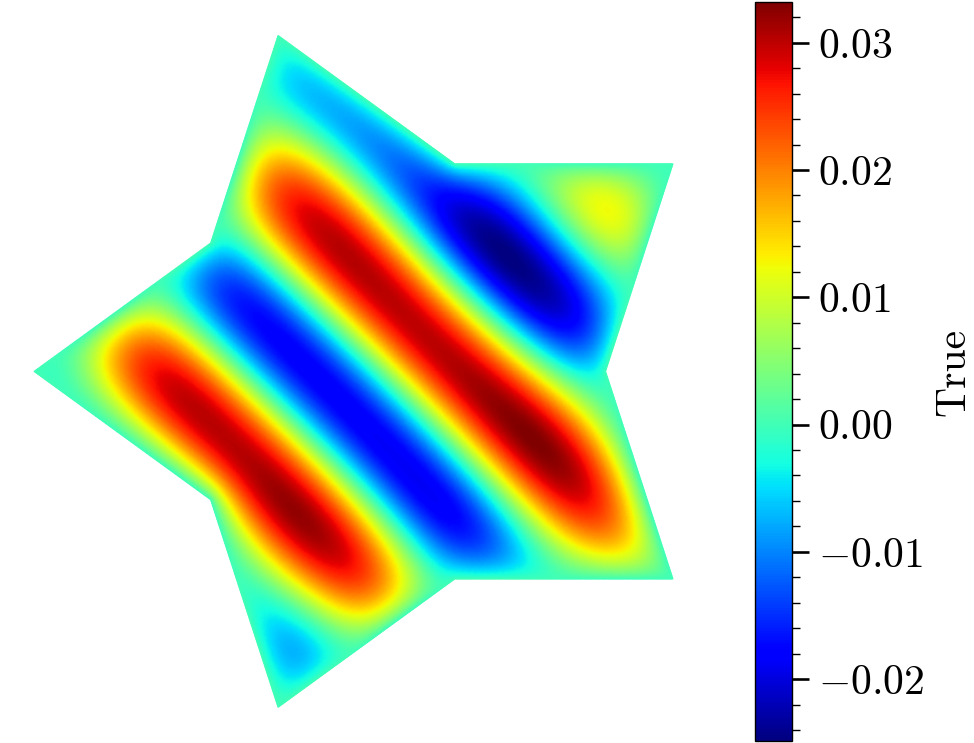

In [8]:
if visualize:
    visualize2D(LS_test[0],rom_data.basis)

### Mean Subtraction

In [9]:
# Compute the mean temperature field across all training snapshots
# This represents the "average" or "reference" temperature distribution
# Shape: [N_dof] - one mean value for each spatial degree of freedom
LS_train_mean = np.mean(LS_train,axis = 0)
# Mean-center the training data by subtracting the mean field
# This creates fluctuations/deviations from the mean temperature distribution
# Shape: [N_train_snapshots, N_dof] - same as original but now mean-centered
# Each row now represents how much each snapshot deviates from the average
LS_train_ms = LS_train - LS_train_mean
#We will use SVD on the mean subtracted matrix data

### Performing SVD on training snapshots

Number of modes selected: 9


Text(0.5, 0, 'POD modes ($k$)')

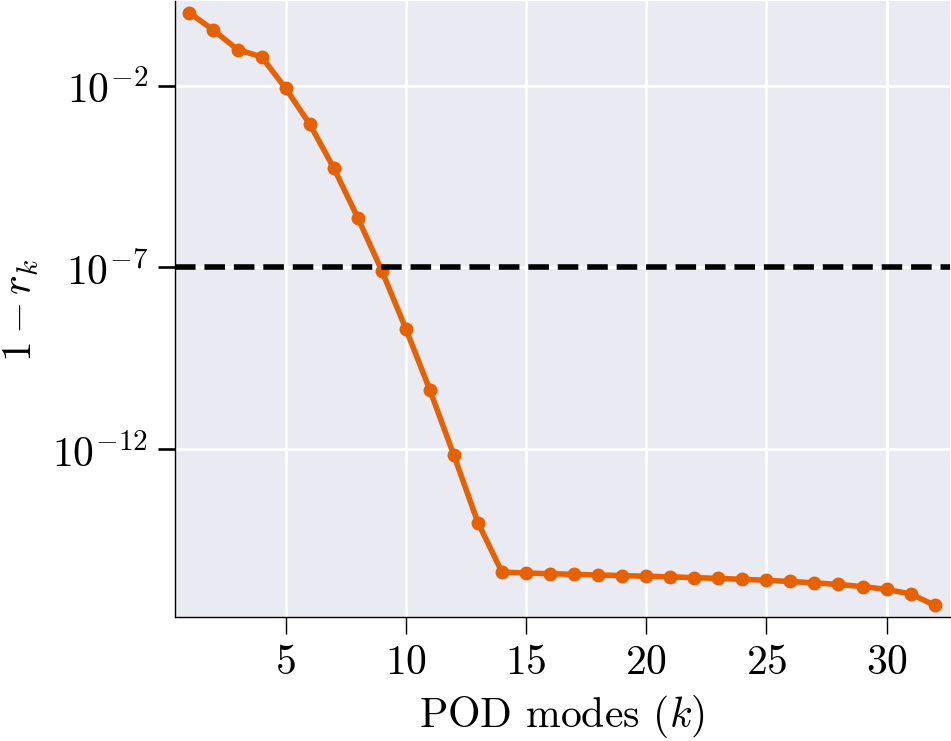

In [ ]:
if run_svd:
    # Configure plot styling for POD analysis visualization
    plt.rcParams['lines.markersize'] = 6      # Set marker size for data points
    plt.rcParams['lines.linewidth'] = 2.0     # Set line thickness for better visibility

    # Perform Singular Value Decomposition (SVD) for POD mode selection
    # SVD decomposes the mean-centered training data to find optimal basis functions
    n_sel, U = svd_mode_selector(LS_train_ms,    # Input: mean-centered training snapshots
                                tolerance=1e-7,    # Convergence criterion for mode selection
                                modes=True)        # Return both number of modes and basis vectors


    # Extract the selected POD basis vectors (spatial modes)
    # V_sel contains the first n_sel most energetic POD modes
    # Shape: [N_dof, n_sel] - each column is a spatial basis function
    V_sel = U[:, :n_sel]  # This will be passed to the ROM simulation function

    # Set axis labels for the POD energy plot (generated by svd_mode_selector)
    plt.ylabel('$1-r_{k}$')           # Energy not captured by first k modes
    plt.xlabel('POD modes ($k$)')     # Number of POD modes retained

## ROM Simulation

In [ ]:
if run_rom:
    # Initialize the reduced-order model (ROM) simulation with affine decomposition for speed-up
    #   V_sel : precomputed basis matrix (e.g., selected POD modes)
    rom = master.rom_simulation(V_sel=V_sel,train_ref=LS_train_mean)

[load_rom_data] loaded from d:\One_drive_folder\OneDrive - Indian Institute of Technology Indian School of Mines Dhanbad\IIT_ISM\RESEARCH\SCIKIT-ROM\scikit-rom\examples\heat_transfer\static\linear\problem_4\ROM_data


In [15]:
if run_rom:
    # Run the reduced-order model (ROM) simulation.
    # rom object will contain the NLS rom simulation solutions and other simulation aspects required by ROM such as the param_list etc.
    rom.run_rom_simulation();

Snap 1/32 params=[4.5164449]

Snap 2/32 params=[1.05781383]
Snap 3/32 params=[2.41075257]
Snap 4/32 params=[5.88208054]
Snap 5/32 params=[5.25553381]
Snap 6/32 params=[1.75163455]
Snap 7/32 params=[0.2045276]
Snap 8/32 params=[3.72121237]
Snap 9/32 params=[3.36006812]
Snap 10/32 params=[0.56559579]
Snap 11/32 params=[2.11283388]
Snap 12/32 params=[4.89460966]
Snap 13/32 params=[5.52087964]
Snap 14/32 params=[2.77167551]
Snap 15/32 params=[1.41895929]
Snap 16/32 params=[4.15537826]
Snap 17/32 params=[3.92500716]
Snap 18/32 params=[1.63180711]
Snap 19/32 params=[2.99779245]
Snap 20/32 params=[5.27830144]
Snap 21/32 params=[4.68123072]
Snap 22/32 params=[2.34267391]
Snap 23/32 params=[0.8087049]
Snap 24/32 params=[3.13448212]
Snap 25/32 params=[3.49828121]
Snap 26/32 params=[0.44462786]
Snap 27/32 params=[1.97881935]
Snap 28/32 params=[5.0451641]
Snap 29/32 params=[5.64215721]
Snap 30/32 params=[2.63386062]
Snap 31/32 params=[1.26800647]
Snap 32/32 params=[4.28908298]


In [13]:
if rom_report:
    #Assign values for the statistics
    LS_rom = np.asarray(rom.rom_solutions)
    ROM_speed_up = rom.speed_up
    ROM_speed_up=ROM_speed_up[1:]
    ROM_relative_error = rom.rom_error

### ROM solution vs. Full order solution performance statistics 

ROM Accuracy Report

Global Errors:
L2 Error:                 1.7018e-09
Relative L2 Error:        1.9839e-09
L∞ Error:                 1.2016e-09
Relative L∞ Error:        1.1234e-08
RMSE:                     6.6750e-11
MAE:                      4.6197e-11

Statistical Fit:
R² Score:                 1.0000
Explained Variance:       1.0000

Error Distribution:
Median Error:             0.0000e+00
95th Percentile Error:    1.3588e-10

Time/Parameter-Dependent Errors:
Average Rel L2 Error over time/parameter: 9.5179e-11
Max Rel L2 Error over time/parameter: 3.9228e-10
Min Rel L2 Error over time/parameter: 1.8707e-12
――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――

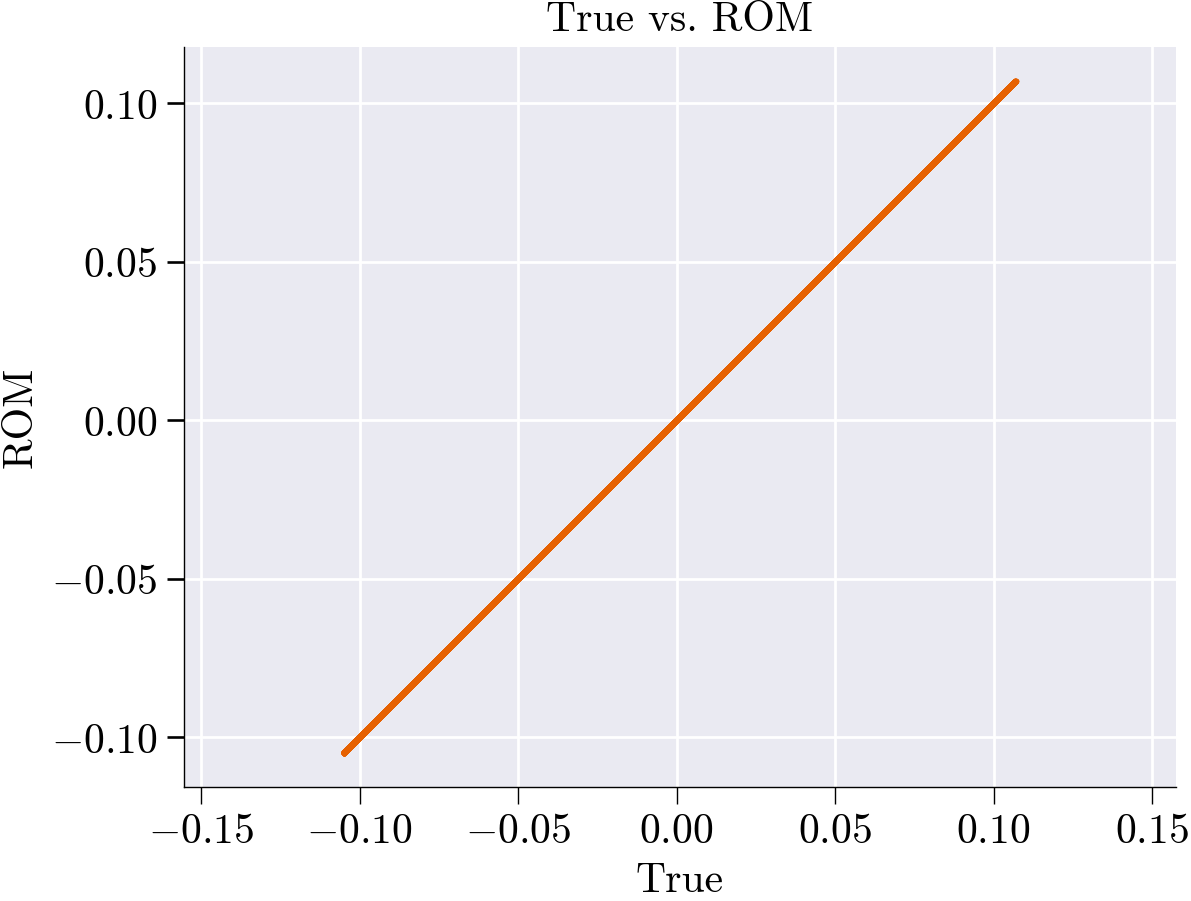

spatial_shape not given → skipping spatial snapshots.
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


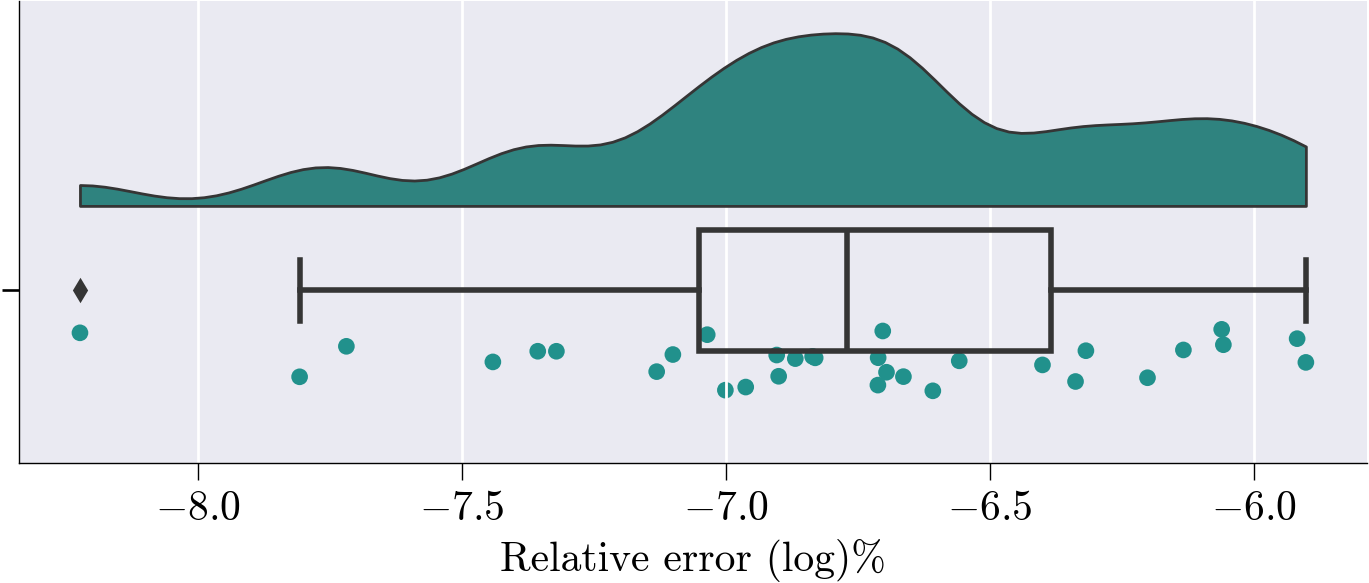

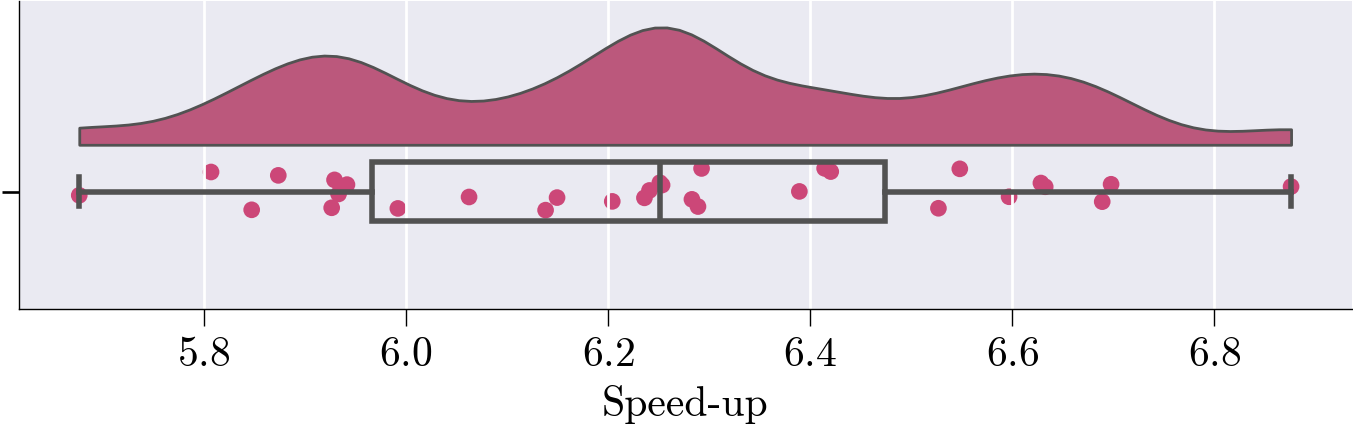

In [14]:
if rom_report:
        
    # --- Hyper-reduced ROM error analysis ---

    # Compute a flat matrix of error metrics comparing true nonlinear solutions to hyper-ROM approximations
    matrix = compute_rom_error_metrics_flat(LS_test, LS_rom)

    # Produce a text-based report summarizing these hyper-ROM error metrics
    generate_rom_error_report(matrix)

    # Plot diagnostic figures: error vs. speed-up for the hyper-reduced ROM
    plot_rom_error_diagnostics_flat(
        LS_test,                   # full-order (true) solution snapshots
        LS_rom,              # hyper-ROM-generated solution snapshots
        ROM_relative_error,   # precomputed relative error of the hyper-ROM
        ROM_speed_up,         # precomputed speed-up factor of the hyper-ROM
        sim_axis=['True', 'ROM'], 
        metrics=matrix              # the matrix of error metrics just computed
    )
